# Import Library

In [ ]:
!pip install numpy scikit-learn pandas joblib skl2onnx matplotlib requests seaborn --quiet

In [94]:
import pandas as pd
import numpy as np
import joblib, warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, rbf_kernel
from sklearn.preprocessing import MinMaxScaler
from sentence_transformers import SentenceTransformer
import scipy.sparse as sp
import requests
import time
import unicodedata

## Data Loading

In [95]:
df = pd.read_csv('dataset_clean.csv', encoding='Latin1')

In [96]:
TMDB_API_KEY = 'ee5943367dc7d8f55b4ad99b291f117f'
BASE_URL = 'https://api.themoviedb.org/3'

In [97]:
if 'Year' not in df.columns:
    df['Year'] = df['Premiere'].apply(lambda x: str(x).split()[-1].strip() if pd.notna(x) else "")

def fetch_real_actors_full(row):
    title = row['Title']
    year = row['Year']
    
    try:
        search_url = f"{BASE_URL}/search/movie"
        search_params = {
            'api_key': TMDB_API_KEY,
            'query': title,
            'primary_release_year': year
        }
        search_res = requests.get(search_url, params=search_params).json()
        
        if not search_res.get('results'):
            return "Unknown"
            
        movie_id = search_res['results'][0]['id']

        credits_url = f"{BASE_URL}/movie/{movie_id}/credits"
        credits_params = {
            'api_key': TMDB_API_KEY
        }
        credits_res = requests.get(credits_url, params=credits_params).json()

        cast_list = credits_res.get('cast', [])

        top_actors = [actor['name'] for actor in cast_list[:4]]

        time.sleep(0.1) 

        return ", ".join(top_actors) if top_actors else "Unknown"

    except Exception:
        return "Unknown"

df['Real_Actor'] = df.apply(fetch_real_actors_full, axis=1)

def fetch_overview(row):
    title = row['Title']
    year  = row['Year']
    try:
        res = requests.get(
            f"{BASE_URL}/search/movie",
            params={'api_key': TMDB_API_KEY, 'query': title, 'primary_release_year': year}
        ).json()
        if not res.get('results'):
            return ""
        return res['results'][0].get('overview', "")
    except Exception:
        return ""
    finally:
        time.sleep(0.1)

df['Overview'] = df.apply(fetch_overview, axis=1)

def get_top_actors(media_type, media_id, top_n=5):

    try:
        url = f"{BASE_URL}/{media_type}/{media_id}/credits"
        res = requests.get(url, params={'api_key': TMDB_API_KEY}).json()
        
        cast = res.get('cast', [])
        if cast:
            actors = [actor.get('name') for actor in cast[:top_n]]
            time.sleep(0.15) 
            return ", ".join(actors)
    except Exception as e:
        pass
    
    return ""

# untuk mengambil aktor dengan mencoba beberapa query berbeda 
def fetch_actor_flexible(row):

    title = row['Title']
    year  = row['Year']
    
    try:
        res = requests.get(
            f"{BASE_URL}/search/movie",
            params={'api_key': TMDB_API_KEY, 'query': title, 'primary_release_year': year}
        ).json()
        
        if res.get('results'):
            movie_id = res['results'][0].get('id')
            time.sleep(0.15)
            actors = get_top_actors('movie', movie_id)
            if actors:
                return actors
    except Exception:
        pass
    
    try:
        res = requests.get(
            f"{BASE_URL}/search/movie",
            params={'api_key': TMDB_API_KEY, 'query': title}
        ).json()
        
        if res.get('results'):
            movie_id = res['results'][0].get('id')
            time.sleep(0.15)
            actors = get_top_actors('movie', movie_id)
            if actors:
                return actors
    except Exception:
        pass
    
    try:
        res = requests.get(
            f"{BASE_URL}/search/tv",
            params={'api_key': TMDB_API_KEY, 'query': title}
        ).json()
        
        if res.get('results'):
            tv_id = res['results'][0].get('id')
            time.sleep(0.15)
            actors = get_top_actors('tv', tv_id)
            if actors:
                return actors
    except Exception:
        pass
    
    time.sleep(0.15)
    return "" 

# untuk mengambil overview dengan mencoba beberapa query berbeda untuk overview yang kosong
def fetch_overview_flexible(row):

    title = row['Title']
    year  = row['Year']
    
    try:
        res = requests.get(
            f"{BASE_URL}/search/movie",
            params={
                'api_key': TMDB_API_KEY,
                'query': title,
                'primary_release_year': year
            }
        ).json()
        
        if res.get('results'):
            overview = res['results'][0].get('overview', '')
            if overview:
                time.sleep(0.15)
                return overview
    except Exception:
        pass
    
    try:
        res = requests.get(
            f"{BASE_URL}/search/movie",
            params={
                'api_key': TMDB_API_KEY,
                'query': title
            }
        ).json()
        
        if res.get('results'):
            for result in res['results'][:3]:
                overview = result.get('overview', '')
                if overview:
                    time.sleep(0.15)
                    return overview
    except Exception:
        pass
    
    try:
        res = requests.get(
            f"{BASE_URL}/search/tv",
            params={
                'api_key': TMDB_API_KEY,
                'query': title
            }
        ).json()
        
        if res.get('results'):
            overview = res['results'][0].get('overview', '')
            if overview:
                time.sleep(0.15)
                return overview
    except Exception:
        pass
    
    time.sleep(0.15)
    return ""  

def fill_empty_overview(row):
    if pd.isna(row['Overview']) or str(row['Overview']).strip() == '':
        return f"A {row['Genre'].lower()} film in {row['Language']} language."
    return row['Overview']

In [98]:
mask_unknown = (
    df['Real_Actor'].isna() | 
    (df['Real_Actor'].astype(str).str.strip() == '') | 
    (df['Real_Actor'].astype(str).str.strip().str.lower() == 'unknown')
)

df_missing = df[mask_unknown]

In [99]:
for idx in df_missing.index:
    new_actors = fetch_actor_flexible(df.loc[idx])
    if new_actors:
        df.at[idx, 'Real_Actor'] = new_actors

In [100]:
still_missing_mask = (
    df['Real_Actor'].isna() | 
    (df['Real_Actor'].astype(str).str.strip() == '') | 
    (df['Real_Actor'].astype(str).str.strip().str.lower() == 'unknown')
)
still_missing = df[still_missing_mask]

In [101]:
for idx in df_missing.index:
    new_overview = fetch_overview_flexible(df.loc[idx])
    df.at[idx, 'Overview'] = new_overview

In [102]:
newdataset = 'dataset_final.csv'
df.to_csv(newdataset, index=False)

In [65]:
df.head(10)

,Title,Genre,Premiere,Runtime,IMDB Score,Language,Year,Real_Actor,Overview,genre_clean,lang_clean,actor_clean,overview_clean,tags
0,Enter the Anime,Documentary,"August 5, 2019",58,2.5,English/Japanese,2019,"Kouzou Morishita, Kenji Kamiyama, Yoko Takahas...",What is anime? Through deep-dives with notable...,documentary,english japanese,kouzoumorishita kenjikamiyama yokotakahashi sh...,what is anime through deepdives with notable m...,documentary documentary documentary documentar...
1,Dark Forces,Thriller,"August 21, 2020",81,2.6,Spanish,2020,"Tenoch Huerta Mejía, Eréndira Ibarra, Ariane P...","In search of his sister, a renegade criminal s...",thriller,spanish,tenochhuertamejia erendiraibarra arianepellice...,in search of his sister a renegade criminal se...,thriller thriller thriller thriller thriller s...
2,The App,Science fiction/Drama,"December 26, 2019",79,2.6,Italian,2019,"Vincenzo Crea, Jessica Cressy, Greta Scarano, ...","Loving girlfriend, family fortune, breakout mo...",sciencefiction drama,italian,vincenzocrea jessicacressy gretascarano mayasansa,loving girlfriend family fortune breakout movi...,sciencefiction drama sciencefiction drama scie...
3,The Open House,Horror thriller,"January 19, 2018",94,3.2,English,2018,"Dylan Minnette, Piercey Dalton, Sharif Atkins,...",A teenager and his mother find themselves besi...,horrorthriller,english,dylanminnette pierceydalton sharifatkins patri...,a teenager and his mother find themselves besi...,horrorthriller horrorthriller horrorthriller h...
4,Kaali Khuhi,Mystery,"October 30, 2020",90,3.4,Hindi,2020,"Shabana Azmi, Riva Arora, Satyadeep Misra, San...",When a restless spirit curses a Punjab village...,mystery,hindi,shabanaazmi rivaarora satyadeepmisra sanjeedas...,when a restless spirit curses a punjab village...,mystery mystery mystery mystery mystery hindi ...
5,Drive,Action,"November 1, 2019",147,3.5,Hindi,2019,"Sushant Singh Rajput, Jacqueline Fernandez, Vi...",A notorious thief allies with a street racer f...,action,hindi,sushantsinghrajput jacquelinefernandez vikramj...,a notorious thief allies with a street racer f...,action action action action action hindi hindi...
6,Leyla Everlasting,Comedy,"December 4, 2020",112,3.7,Turkish,2020,"Demet Akbağ, Haluk Bilginer, Elçin Sangu, Alic...","A resilient housewife, her husband and their m...",comedy,turkish,demetakbag halukbilginer elcinsangu alicanyucesoy,a resilient housewife her husband and their ma...,comedy comedy comedy comedy comedy turkish tur...
7,The Last Days of American Crime,Heist film/Thriller,"June 5, 2020",149,3.7,English,2020,"Edgar Ramírez, Michael Pitt, Anna Brewster, Sh...","In the not-too-distant future, as a final resp...",heistfilm thriller,english,edgarramirez michaelpitt annabrewster sharltoc...,in the nottoodistant future as a final respons...,heistfilm thriller heistfilm thriller heistfil...
8,Paradox,Musical/Western/Fantasy,"March 23, 2018",73,3.9,English,2018,"Gugu Mbatha-Raw, Daniel Brühl, Chris O'Dowd, D...","Orbiting above a planet on the brink of war, s...",musical western fantasy,english,gugumbatha-raw danielbruhl chriso'dowd davidoy...,orbiting above a planet on the brink of war sc...,musical western fantasy musical western fantas...
9,Sardar Ka Grandson,Comedy,"May 18, 2021",139,4.1,Hindi,2021,"Arjun Kapoor, Neena Gupta, Rakul Preet Singh, ...",A devoted grandson's mission to reunite his ai...,comedy,hindi,arjunkapoor neenagupta rakulpreetsingh kumudmi...,a devoted grandsons mission to reunite his ail...,comedy comedy comedy comedy comedy hindi hindi...


## Exploratory Data Analysis (EDA)

In [66]:
df.info()
missing = df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 584 entries, 0 to 583
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Title           584 non-null    str    
 1   Genre           584 non-null    str    
 2   Premiere        584 non-null    str    
 3   Runtime         584 non-null    int64  
 4   IMDB Score      584 non-null    float64
 5   Language        584 non-null    str    
 6   Year            584 non-null    int64  
 7   Real_Actor      584 non-null    str    
 8   Overview        584 non-null    str    
 9   genre_clean     584 non-null    str    
 10  lang_clean      584 non-null    str    
 11  actor_clean     584 non-null    str    
 12  overview_clean  584 non-null    str    
 13  tags            584 non-null    str    
dtypes: float64(1), int64(2), str(11)
memory usage: 64.0 KB


In [67]:
df.describe()

,Runtime,IMDB Score,Year
count,584.000000,584.000000,584.000000
mean,93.577055,6.271747,2018.936644
std,27.761683,0.979256,1.473992
min,4.000000,2.500000,2014.000000
25%,86.000000,5.700000,2018.000000
50%,97.000000,6.350000,2019.000000
75%,108.000000,7.000000,2020.000000
max,209.000000,9.000000,2021.000000


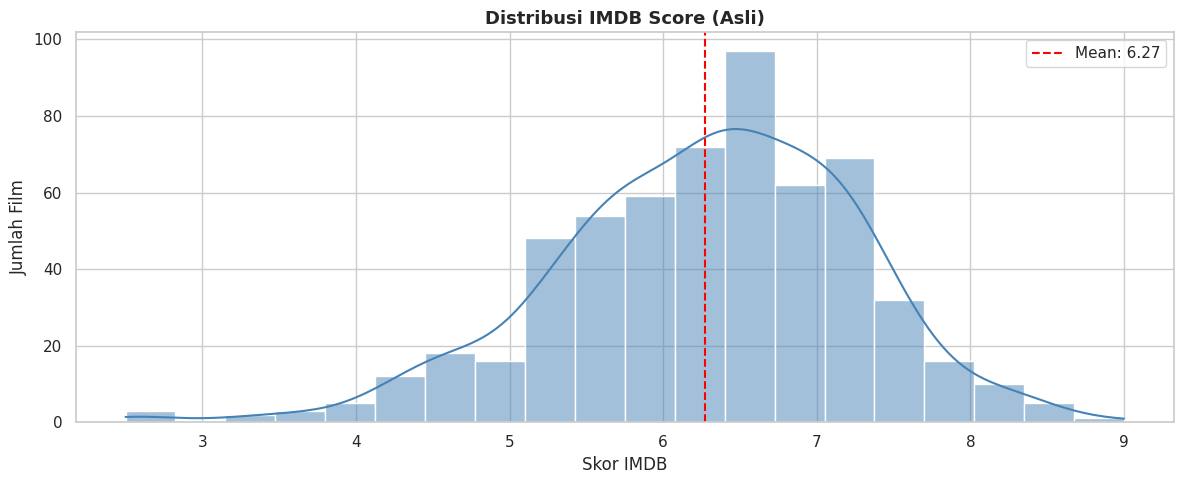

In [68]:
plt.figure(figsize=(12, 5))

sns.histplot(df['IMDB Score'], bins=20, kde=True, color='steelblue')
plt.axvline(df['IMDB Score'].mean(), color='red', linestyle='--', label=f'Mean: {df["IMDB Score"].mean():.2f}')

plt.title('Distribusi IMDB Score (Asli)', fontsize=13, fontweight='bold')
plt.xlabel('Skor IMDB')
plt.ylabel('Jumlah Film')
plt.legend()

plt.tight_layout()
plt.show()

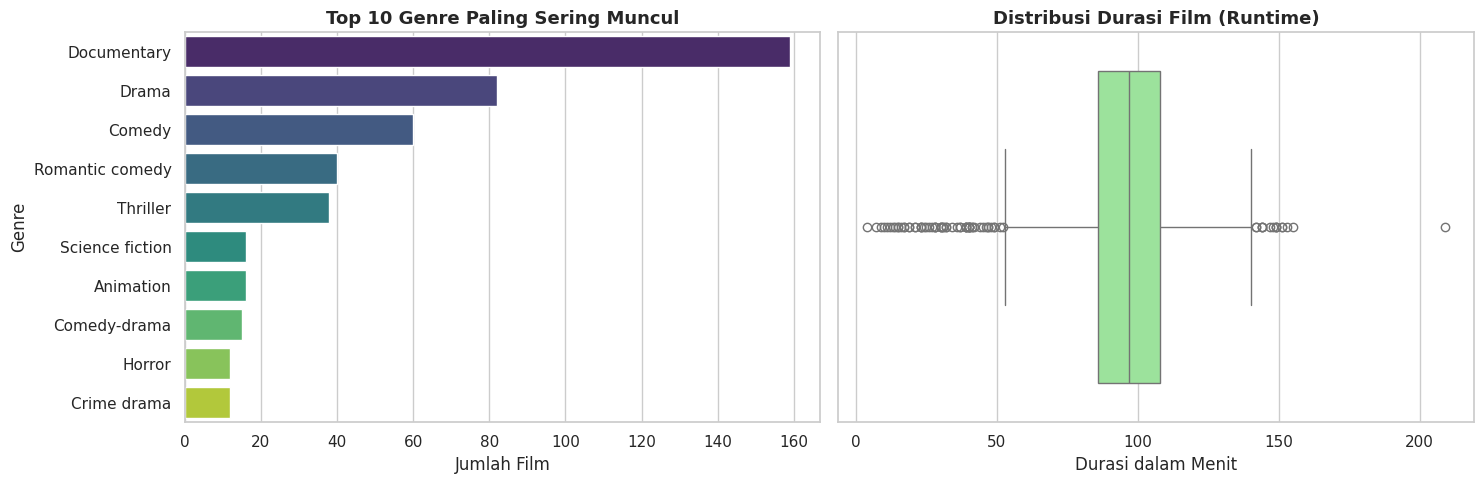

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

all_genres = df['Genre'].dropna().str.split('/').explode().str.strip()
top_genres = all_genres.value_counts().head(10)
sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis', ax=axes[0])
axes[0].set_title('Top 10 Genre Paling Sering Muncul', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Jumlah Film')

sns.boxplot(x=df['Runtime'], color='lightgreen', ax=axes[1])
axes[1].set_title('Distribusi Durasi Film (Runtime)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Durasi dalam Menit')

plt.tight_layout()
plt.show()

## Data Preprocessing

In [70]:
df_missing = df[df['Overview'].isna() | (df['Overview'].str.strip() == '')]

In [71]:
df.head()

,Title,Genre,Premiere,Runtime,IMDB Score,Language,Year,Real_Actor,Overview,genre_clean,lang_clean,actor_clean,overview_clean,tags
0,Enter the Anime,Documentary,"August 5, 2019",58,2.5,English/Japanese,2019,"Kouzou Morishita, Kenji Kamiyama, Yoko Takahas...",What is anime? Through deep-dives with notable...,documentary,english japanese,kouzoumorishita kenjikamiyama yokotakahashi sh...,what is anime through deepdives with notable m...,documentary documentary documentary documentar...
1,Dark Forces,Thriller,"August 21, 2020",81,2.6,Spanish,2020,"Tenoch Huerta Mejía, Eréndira Ibarra, Ariane P...","In search of his sister, a renegade criminal s...",thriller,spanish,tenochhuertamejia erendiraibarra arianepellice...,in search of his sister a renegade criminal se...,thriller thriller thriller thriller thriller s...
2,The App,Science fiction/Drama,"December 26, 2019",79,2.6,Italian,2019,"Vincenzo Crea, Jessica Cressy, Greta Scarano, ...","Loving girlfriend, family fortune, breakout mo...",sciencefiction drama,italian,vincenzocrea jessicacressy gretascarano mayasansa,loving girlfriend family fortune breakout movi...,sciencefiction drama sciencefiction drama scie...
3,The Open House,Horror thriller,"January 19, 2018",94,3.2,English,2018,"Dylan Minnette, Piercey Dalton, Sharif Atkins,...",A teenager and his mother find themselves besi...,horrorthriller,english,dylanminnette pierceydalton sharifatkins patri...,a teenager and his mother find themselves besi...,horrorthriller horrorthriller horrorthriller h...
4,Kaali Khuhi,Mystery,"October 30, 2020",90,3.4,Hindi,2020,"Shabana Azmi, Riva Arora, Satyadeep Misra, San...",When a restless spirit curses a Punjab village...,mystery,hindi,shabanaazmi rivaarora satyadeepmisra sanjeedas...,when a restless spirit curses a punjab village...,mystery mystery mystery mystery mystery hindi ...


In [72]:
df['Genre']      = df['Genre'].fillna('')
df['Language']   = df['Language'].fillna('')
df['Real_Actor'] = df['Real_Actor'].fillna('')
df['Overview'] = df['Overview'].fillna('')

In [73]:
import re


def parse_genre_set(g: str) -> set:
    parts = re.split(r'[/,]', g.lower().strip())
    return {p.strip() for p in parts if p.strip()}

def genre_overlap(g1: str, g2: str) -> int:
    return len(parse_genre_set(g1) & parse_genre_set(g2))

def genre_compatible(src_genre: str, cand_genre: str) -> bool:
    src_set  = parse_genre_set(src_genre)
    cand_set = parse_genre_set(cand_genre)

    if len(src_set & cand_set) >= 1:
        return True

    src_words  = set(' '.join(src_set).replace('-', ' ').split())
    cand_words = set(' '.join(cand_set).replace('-', ' ').split())
    return len(src_words & cand_words) >= 1

def clean_tag_field(x):
    if not isinstance(x, str) or not x.strip():
        return ''
    x = unicodedata.normalize('NFKD', x).encode('ascii', 'ignore').decode('utf-8')
    sep = ',' if ',' in x else '/'
    tokens = [re.sub(r'\s+', '', t.lower().strip()) for t in x.split(sep)]
    return ' '.join(tokens)

def clean_overview(x):
    if not isinstance(x, str) or not x.strip():
        return ''
    x = unicodedata.normalize('NFKD', x).encode('ascii', 'ignore').decode('utf-8')
    x = re.sub(r'[^a-z0-9\s]', '', x.lower())
    return re.sub(r'\s+', ' ', x).strip()

In [74]:
df['genre_clean']    = df['Genre'].map(clean_tag_field)
df['lang_clean']     = df['Language'].map(clean_tag_field)
df['actor_clean']    = df['Real_Actor'].map(clean_tag_field)
df['overview_clean'] = df['Overview'].fillna('').map(clean_overview)

df['tags'] = (
    df['genre_clean'].apply(lambda x: ' '.join([x] * 5)) + ' ' +
    df['lang_clean'].apply(lambda x: ' '.join([x] * 2)) + ' ' +
    df['actor_clean'] + ' ' +
    df['overview_clean']
).apply(lambda x: ' '.join(x.split()))

In [75]:
df.head()

,Title,Genre,Premiere,Runtime,IMDB Score,Language,Year,Real_Actor,Overview,genre_clean,lang_clean,actor_clean,overview_clean,tags
0,Enter the Anime,Documentary,"August 5, 2019",58,2.5,English/Japanese,2019,"Kouzou Morishita, Kenji Kamiyama, Yoko Takahas...",What is anime? Through deep-dives with notable...,documentary,english japanese,kouzoumorishita kenjikamiyama yokotakahashi sh...,what is anime through deepdives with notable m...,documentary documentary documentary documentar...
1,Dark Forces,Thriller,"August 21, 2020",81,2.6,Spanish,2020,"Tenoch Huerta Mejía, Eréndira Ibarra, Ariane P...","In search of his sister, a renegade criminal s...",thriller,spanish,tenochhuertamejia erendiraibarra arianepellice...,in search of his sister a renegade criminal se...,thriller thriller thriller thriller thriller s...
2,The App,Science fiction/Drama,"December 26, 2019",79,2.6,Italian,2019,"Vincenzo Crea, Jessica Cressy, Greta Scarano, ...","Loving girlfriend, family fortune, breakout mo...",sciencefiction drama,italian,vincenzocrea jessicacressy gretascarano mayasansa,loving girlfriend family fortune breakout movi...,sciencefiction drama sciencefiction drama scie...
3,The Open House,Horror thriller,"January 19, 2018",94,3.2,English,2018,"Dylan Minnette, Piercey Dalton, Sharif Atkins,...",A teenager and his mother find themselves besi...,horrorthriller,english,dylanminnette pierceydalton sharifatkins patri...,a teenager and his mother find themselves besi...,horrorthriller horrorthriller horrorthriller h...
4,Kaali Khuhi,Mystery,"October 30, 2020",90,3.4,Hindi,2020,"Shabana Azmi, Riva Arora, Satyadeep Misra, San...",When a restless spirit curses a Punjab village...,mystery,hindi,shabanaazmi rivaarora satyadeepmisra sanjeedas...,when a restless spirit curses a punjab village...,mystery mystery mystery mystery mystery hindi ...


## Feature Engineering

In [76]:
tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)
tfidf_matrix = tfidf.fit_transform(df['tags'])

scaler = MinMaxScaler()
num_features = scaler.fit_transform(
    df[['IMDB Score', 'Runtime']].fillna(df[['IMDB Score', 'Runtime']].median())
)
num_sparse   = sp.csr_matrix(num_features * 0.15)
combined_matrix = sp.hstack([tfidf_matrix, num_sparse])

cosine_sim = cosine_similarity(combined_matrix, combined_matrix)
indices    = pd.Series(df.index, index=df['Title']).groupby(level=0).first()

# Tuning

In [ ]:
hf_token = ""

In [78]:
class HybridMovieRecommender:
    def __init__(self, weights=None):
        self.weights = weights if weights else {
            'semantic_story': 0.50, 
            'metadata': 0.35,       
            'numerical': 0.15       
        }
        self.df = None
        self.indices = None
        self.final_sim_matrix = None
        
        self.nlp_model = SentenceTransformer('all-MiniLM-L6-v2')
        
    def fit(self, df):
        self.df = df.reset_index(drop=True)
        self.indices = pd.Series(self.df.index, index=self.df['Title']).groupby(level=0).first()
        

        overview_embeddings = self.nlp_model.encode(self.df['Overview'].fillna('').tolist(), show_progress_bar=True)
        sim_story = cosine_similarity(overview_embeddings, overview_embeddings)
        
        metadata = (
            self.df['Genre'].fillna('').str.replace(' ', '').str.replace('/', ' ') + " " +
            self.df['Real_Actor'].fillna('').str.replace(' ', '').str.replace(',', ' ') + " " +
            self.df['Language'].fillna('')
        )
        tfidf = TfidfVectorizer(token_pattern=r'(?u)\b\w+\b', min_df=2)
        meta_matrix = tfidf.fit_transform(metadata)
        sim_meta = cosine_similarity(meta_matrix, meta_matrix)
        
        scaler = MinMaxScaler()
        num_features = scaler.fit_transform(self.df[['IMDB Score', 'Runtime']].fillna(self.df[['IMDB Score', 'Runtime']].median()))
        sim_num = rbf_kernel(num_features, gamma=0.5) 
        
        self.final_sim_matrix = (
            (self.weights['semantic_story'] * sim_story) +
            (self.weights['metadata'] * sim_meta) +
            (self.weights['numerical'] * sim_num)
        )
        return self
        
    def recommend(self, title, top_n=5):
        if title not in self.indices:
            return f"Error: Film '{title}' tidak ditemukan."
            
        idx = self.indices[title]
        
        sim_scores = list(enumerate(self.final_sim_matrix[idx]))
        
        sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:top_n+1]
        
        movie_indices = [i[0] for i in sim_scores]
        scores = [round(i[1], 4) for i in sim_scores]
        
        recs = self.df.iloc[movie_indices][['Title', 'Genre', 'Real_Actor', 'IMDB Score', 'Runtime']].copy()
        recs['Similarity Score'] = scores
        
        return recs.reset_index(drop=True)
    
    def save_pipeline(self, path='model_hybrid.pkl'):
        joblib.dump({
            'similarity_matrix': self.final_sim_matrix,
            'indices': self.indices,
            'dataframe': self.df[['Title', 'Genre', 'Real_Actor', 'IMDB Score', 'Runtime', 'Year']]
        }, path)

## Model Training

In [79]:
def recommend_popular(top_n: int = 10) -> pd.DataFrame:
    return (
        df[['Title', 'Genre', 'IMDB Score', 'Runtime', 'Language']]
        .sort_values('IMDB Score', ascending=False)
        .drop_duplicates(subset='Title')
        .head(top_n)
        .reset_index(drop=True)
    )

def get_cbf_recommendations(
    title: str,
    top_n: int = 10,
    min_similarity: float = 0.05,
    relative_cutoff: float = 0.25,
    genre_filter: bool = True,
    verbose: bool = False
) -> pd.DataFrame:
    if title not in indices:
        return pd.DataFrame()

    idx       = indices[title]
    src_genre = df.loc[idx, 'Genre']
    sims      = sorted(enumerate(cosine_sim[idx]), key=lambda x: x[1], reverse=True)
    sims      = [(i, s) for i, s in sims if i != idx and s >= min_similarity]

    if not sims:
        return recommend_popular(top_n)

    top_score = sims[0][1]
    sims = [(i, s) for i, s in sims if s >= top_score * relative_cutoff]

    if genre_filter:
        sims = [(i, s) for i, s in sims
                if genre_compatible(src_genre, df.loc[i, 'Genre'])]

    n_organic = len(sims)
    if verbose and n_organic < top_n:
        pass
    if not sims:
        return recommend_popular(top_n)

    top_idx    = [i for i, _ in sims[:top_n]]
    top_scores = [round(s, 4) for _, s in sims[:top_n]]
    result = df[['Title', 'Genre', 'IMDB Score', 'Runtime', 'Language']].iloc[top_idx].copy()
    result['similarity_score'] = top_scores
    return result.reset_index(drop=True)

def get_hybrid_recommendations(
    title: str,
    top_n: int = 10,
    min_similarity: float = 0.1,  
    genre_filter: bool = False,   
    verbose: bool = False
) -> pd.DataFrame:
    if title not in indices:
        return pd.DataFrame()

    idx = indices[title]
    src_genre = df.loc[idx, 'Genre']
    
    sim_scores = list(enumerate(cosine_sim[idx]))
    
    sims = [(i, s) for i, s in sim_scores if i != idx and s >= min_similarity]

    if not sims:
        return recommend_popular(top_n)

    sims = sorted(sims, key=lambda x: x[1], reverse=True)

    if genre_filter:
        sims = [(i, s) for i, s in sims if genre_compatible(src_genre, df.loc[i, 'Genre'])]

    if not sims:
        return recommend_popular(top_n)

    top_idx = [i for i, _ in sims[:top_n]]
    top_scores = [round(s, 4) for _, s in sims[:top_n]]
    
    result = df[['Title', 'Genre', 'Real_Actor', 'IMDB Score', 'Runtime']].iloc[top_idx].copy()
    result['Hybrid_Score'] = top_scores
    return result.reset_index(drop=True)

In [80]:
sample_title = df['Title'].iloc[0]
get_cbf_recommendations(sample_title, top_n=5)

,Title,Genre,IMDB Score,Runtime,Language,similarity_score
0,Voyuer,Documentary,6.2,95,English,0.2710
1,Notes from Dunblane: Lesson from a School Shoo...,Documentary,5.9,23,English,0.2696
2,Little Miss Sumo,Documentary,6.7,19,Japanese,0.2524
3,Nail Bomber: Manhunt,Documentary,6.3,72,English,0.2161
4,Fyre: The Greatest Party That Never Happened,Documentary,7.2,97,English,0.2091


In [81]:
recommender = HybridMovieRecommender(weights={
    'semantic_story': 0.45,  
    'metadata': 0.40,        
    'numerical': 0.15         
})

recommender.fit(df)

Batches: 100%|██████████| 19/19 [00:00<00:00, 95.11it/s]


## Evaluasi Model

In [82]:
def build_genre_ground_truth(df: pd.DataFrame, min_shared_genres: int = 1) -> dict:
    ground_truth = {}
    for i, row in df.iterrows():
        src = parse_genre_set(row['Genre'])
        relevant = []
        for j, row2 in df.iterrows():
            if i == j:
                continue
            if len(src & parse_genre_set(row2['Genre'])) >= min_shared_genres:
                relevant.append(row2['Title'])
        ground_truth[row['Title']] = set(relevant)
    return ground_truth

def evaluate_cbf(
    ground_truth: dict,
    k_values: list = [5, 10, 20],
    sample_n: int = 50,
    random_state: int = 42
) -> pd.DataFrame:
    np.random.seed(random_state)
    sample_titles = (
        df['Title'].drop_duplicates()
        .sample(min(sample_n, len(df)), random_state=random_state)
        .tolist()
    )
    results = []
    for k in k_values:
        precisions, recalls, coverages = [], [], []
        for title in sample_titles:
            if title not in ground_truth or title not in indices:
                continue
            recs = get_cbf_recommendations(title, top_n=k, verbose=False)
            if recs.empty:
                continue
            recommended_set = set(recs['Title'].tolist())
            relevant_set    = ground_truth[title]
            if not relevant_set:
                continue
            tp = len(recommended_set & relevant_set)
            precisions.append(tp / k)
            recalls.append(tp / len(relevant_set))
            coverages.append(len(recommended_set) / k)

        p = np.mean(precisions)
        r = np.mean(recalls)
        results.append({
            'k'           : k,
            'precision@k' : round(p, 4),
            'recall@k'    : round(r, 4),
            'f1@k'        : round(2 * p * r / (p + r + 1e-9), 4),
            'coverage'    : round(np.mean(coverages), 4),
            'n_evaluated' : len(precisions)
        })

    return pd.DataFrame(results)

def evaluate_hybrid_model(
    ground_truth: dict,
    k_values: list = [5, 10, 20],
    sample_n: int = 50,
    random_state: int = 42
) -> pd.DataFrame:
    
    np.random.seed(random_state)
    
    valid_titles = [t for t in df['Title'].drop_duplicates().tolist() if t in ground_truth and t in indices]
    sample_titles = np.random.choice(valid_titles, min(sample_n, len(valid_titles)), replace=False)
    
    results = []
    
    for k in k_values:
        precisions, recalls, mrrs = [], [], []
        
        for title in sample_titles:
            recs = get_hybrid_recommendations(title, top_n=k, min_similarity=0.0, genre_filter=False)
            if recs.empty:
                continue
                
            recommended_list = recs['Title'].tolist()
            relevant_set = ground_truth[title]
            
            if not relevant_set:
                continue
            
            tp = len(set(recommended_list) & relevant_set)
            precisions.append(tp / k)
            recalls.append(tp / len(relevant_set))
            
            mrr_score = 0
            for rank, rec_title in enumerate(recommended_list, 1):
                if rec_title in relevant_set:
                    mrr_score = 1 / rank
                    break 
            mrrs.append(mrr_score)

        p = np.mean(precisions)
        r = np.mean(recalls)
        mrr = np.mean(mrrs)
        
        results.append({
            'K (Top-N)': k,
            'Precision@K': round(p, 4),
            'Recall@K': round(r, 4),
            'F1-Score': round(2 * p * r / (p + r + 1e-9), 4),
            'MRR': round(mrr, 4)
        })

    eval_df = pd.DataFrame(results)
    return eval_df


In [83]:
gt = build_genre_ground_truth(df, min_shared_genres=1)

eval_hybrid = evaluate_hybrid_model(gt, k_values=[5, 10, 20], sample_n=100)
display(eval_hybrid)

,K (Top-N),Precision@K,Recall@K,F1-Score,MRR
0,5,0.9255,0.2814,0.4316,0.9787
1,10,0.8521,0.3724,0.5183,0.9787
2,20,0.7739,0.4858,0.5969,0.9787


### Visualisasi Hasil Evaluasi

#### 1. Metrik Evaluasi per K (Precision, Recall, F1-Score)

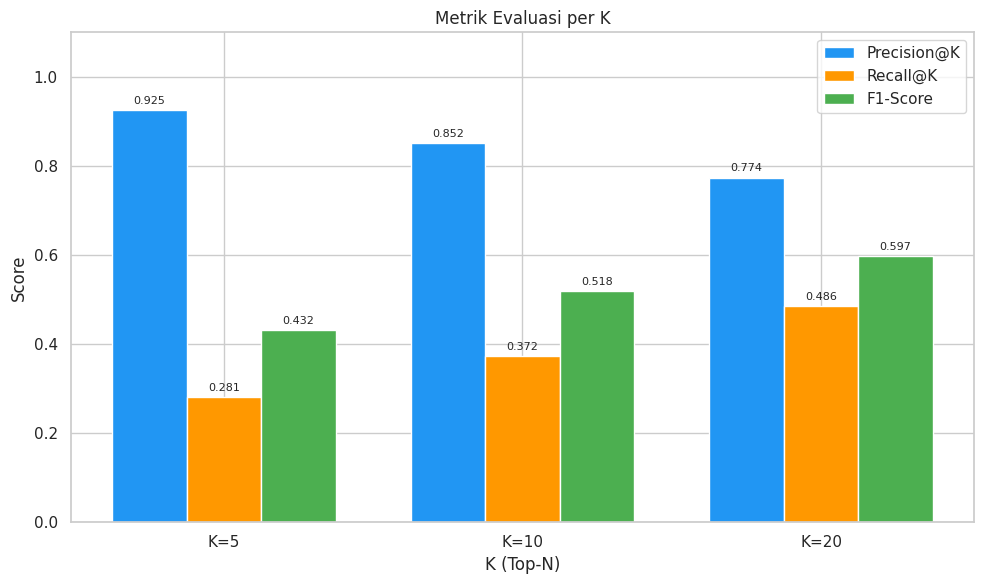

In [85]:
fig, ax1 = plt.subplots(figsize=(10, 6))
k_values = eval_hybrid['K (Top-N)'].tolist()
x = np.arange(len(k_values))
width = 0.25

bars1 = ax1.bar(x - width, eval_hybrid['Precision@K'], width, label='Precision@K', color='#2196F3')
bars2 = ax1.bar(x, eval_hybrid['Recall@K'], width, label='Recall@K', color='#FF9800')
bars3 = ax1.bar(x + width, eval_hybrid['F1-Score'], width, label='F1-Score', color='#4CAF50')

ax1.set_xlabel('K (Top-N)')
ax1.set_ylabel('Score')
ax1.set_title('Metrik Evaluasi per K')
ax1.set_xticks(x)
ax1.set_xticklabels([f'K={k}' for k in k_values])
ax1.legend()
ax1.set_ylim(0, 1.1)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax1.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


#### 2. Mean Reciprocal Rank (MRR) per K

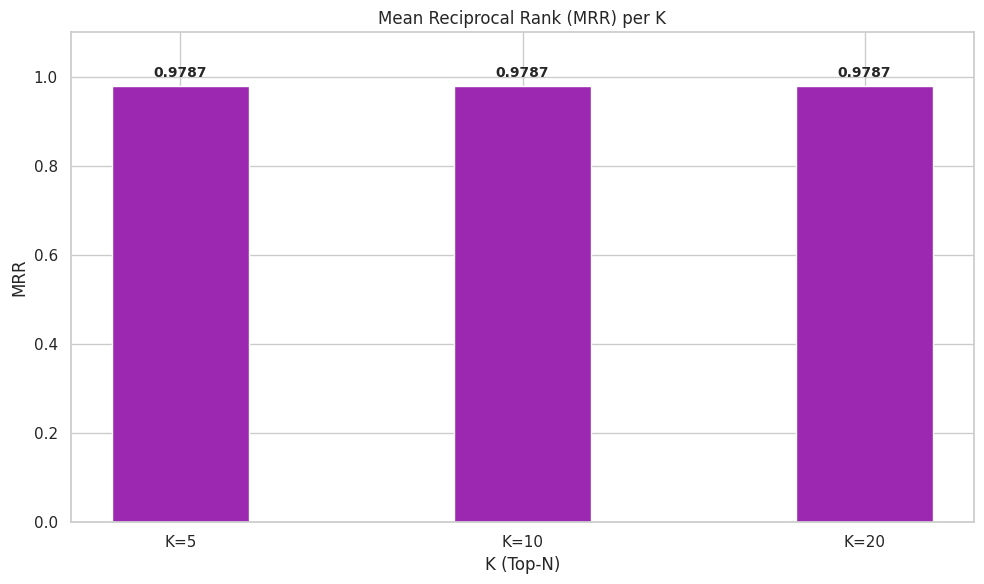

In [86]:
fig, ax2 = plt.subplots(figsize=(10, 6))
k_values = eval_hybrid['K (Top-N)'].tolist()
x = np.arange(len(k_values))

ax2.bar(x, eval_hybrid['MRR'], width=0.4, color='#9C27B0')
ax2.set_xlabel('K (Top-N)')
ax2.set_ylabel('MRR')
ax2.set_title('Mean Reciprocal Rank (MRR) per K')
ax2.set_xticks(x)
ax2.set_xticklabels([f'K={k}' for k in k_values])
ax2.set_ylim(0, 1.1)

for i, v in enumerate(eval_hybrid['MRR']):
    ax2.text(i, v + 0.02, f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


#### 3. Cosine Similarity Heatmap

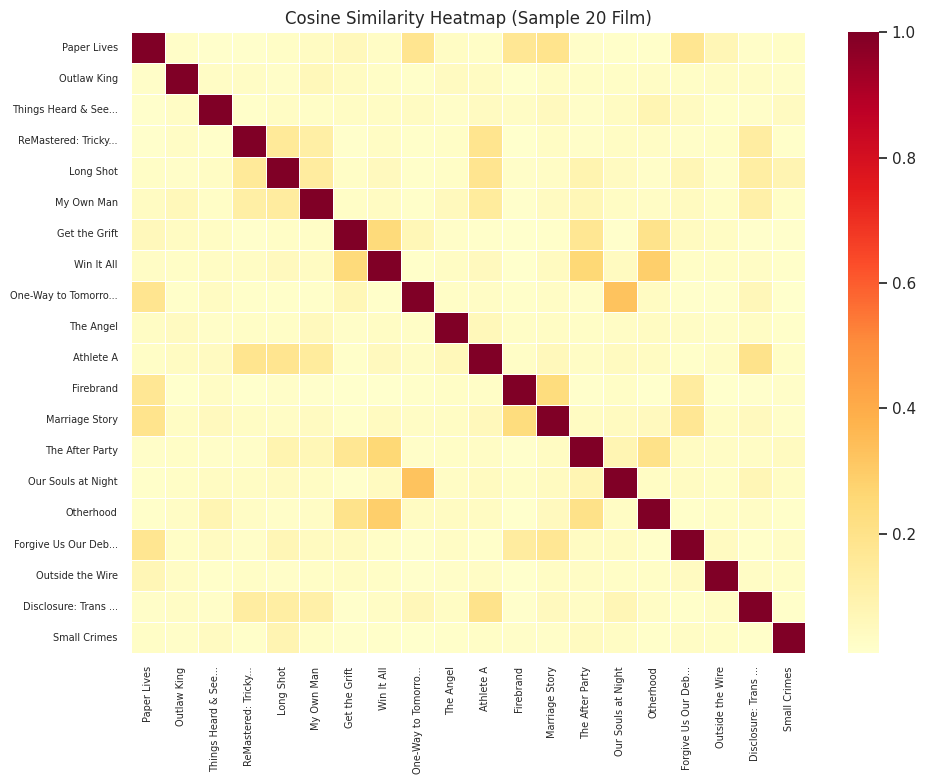

In [87]:
fig, ax3 = plt.subplots(figsize=(10, 8))
sample_n = 20
np.random.seed(42)
sample_indices = np.random.choice(len(df), sample_n, replace=False)
sample_titles_viz = df['Title'].iloc[sample_indices].tolist()
sample_sim = cosine_sim[np.ix_(sample_indices, sample_indices)]

short_titles = [t[:18] + '...' if len(t) > 18 else t for t in sample_titles_viz]
sns.heatmap(sample_sim, ax=ax3, cmap='YlOrRd', xticklabels=short_titles, yticklabels=short_titles,
            annot=False, fmt='.2f', linewidths=0.5)
ax3.set_title('Cosine Similarity Heatmap (Sample 20 Film)')
ax3.tick_params(axis='x', rotation=90, labelsize=7)
ax3.tick_params(axis='y', rotation=0, labelsize=7)

plt.tight_layout()
plt.show()


#### 4. Distribusi IMDB Score

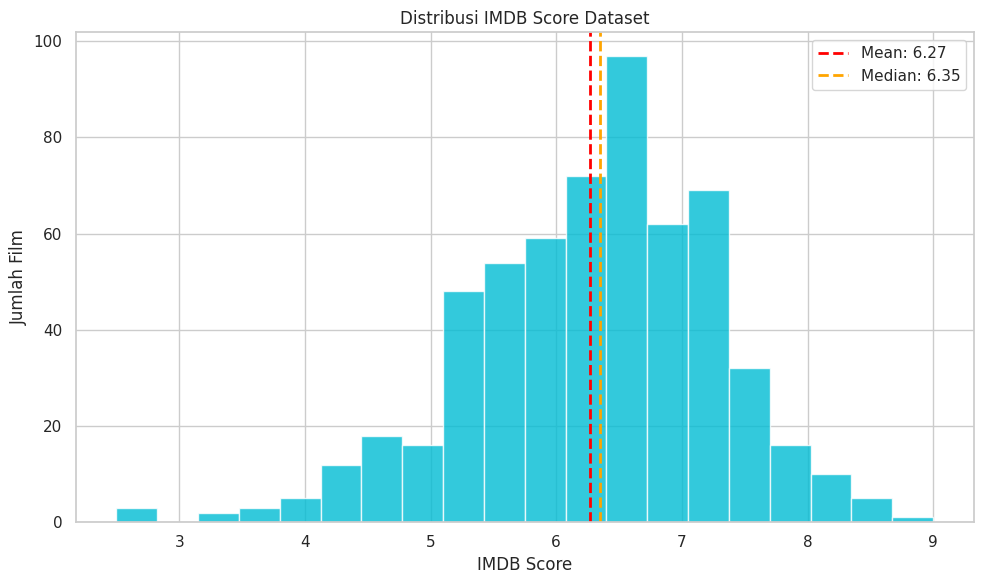

In [88]:
fig, ax4 = plt.subplots(figsize=(10, 6))
ax4.hist(df['IMDB Score'], bins=20, color='#00BCD4', edgecolor='white', alpha=0.8)
ax4.axvline(df['IMDB Score'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df['IMDB Score'].mean():.2f}")
ax4.axvline(df['IMDB Score'].median(), color='orange', linestyle='--', linewidth=2, label=f"Median: {df['IMDB Score'].median():.2f}")
ax4.set_xlabel('IMDB Score')
ax4.set_ylabel('Jumlah Film')
ax4.set_title('Distribusi IMDB Score Dataset')
ax4.legend()

plt.tight_layout()
plt.show()


## Simpan Model

In [92]:
# TF-IDF vectorizer & cosine sim matrix
joblib.dump(tfidf,      'model/tfidf_vectorizer.pkl')
joblib.dump(cosine_sim, 'model/cosine_sim_matrix.pkl')

recommender.save_pipeline('model/hybrid_recommender.pkl')
# Dataset + features
df.to_csv('model/df_processed.csv', index=False)

## Test Sistem Rekomendasi


In [93]:
for title in ['David Attenborough: A Life on Our Planet', 'Taylor Swift: Reputation Stadium Tour', 'The App']:
    print(f"\nTop 5 rekomendasi untuk '{title}':")
    result = get_cbf_recommendations(title, top_n=5, verbose=True)
    if not result.empty:
        print(result[['Title', 'Genre', 'IMDB Score', 'similarity_score']].to_string(index=False))
    print("=" * 100)


Top 5 rekomendasi untuk 'David Attenborough: A Life on Our Planet':
                                       Title       Genre  IMDB Score  similarity_score
Have a Good Trip: Adventures in Psychedelics Documentary         6.8            0.2580
         Guillermo Vilas: Settling the Score Documentary         7.1            0.2376
                                    End Game Documentary         7.1            0.2082
               They'll Love Me When I'm Dead Documentary         7.4            0.1933
                            Out of Many, One Documentary         5.7            0.1824

Top 5 rekomendasi untuk 'Taylor Swift: Reputation Stadium Tour':
                                      Title        Genre  IMDB Score  similarity_score
       Ariana Grande: Excuse Me, I Love You Concert Film         6.4            0.5653
Barbra: The Music, The Mem'ries, The Magic! Concert Film         7.5            0.4871
              Shawn Mendes: Live in Concert Concert Film         7.4            0.